In [1]:
import warnings; warnings.simplefilter('ignore')
import hotspot
import scanpy as sc
import muon as mu
import numpy as np
import mplscience
import anndata

In [2]:
mdata = anndata.read_h5ad('/home/data/t120425/epilepsy/temp/temp.h5ad')
mdata

AnnData object with n_obs × n_vars = 107435 × 28306
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'idents', 'percent.mt', 'percent.rb', 'percent.HB', 'Anno_Idents', 'group', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1'
    var: 'features'

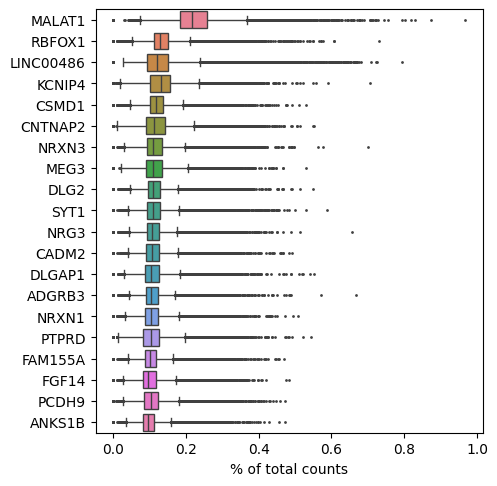

In [3]:
# 确保所有基因名称都是唯一的
mdata.var_names_make_unique()

# 移除少于200个基因的细胞
sc.pp.filter_cells(mdata, min_genes=200)

# 移除在少于3个细胞中表达的基因
sc.pp.filter_genes(mdata, min_cells=3)

# 展示在每个细胞中产生最高计数的基因
sc.pl.highest_expr_genes(mdata, n_top=20)

In [4]:
# 将线粒体基因组标注为'mt'
mdata.var['mt'] = mdata.var_names.str.startswith('MT-') 
 
# 将核糖体蛋白组标注为'rb'
mdata.var['rb'] = mdata.var_names.str.startswith(('RPS','RPL')) 

# 计算
sc.pp.calculate_qc_metrics(mdata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(mdata, qc_vars=['rb'], percent_top=None, log1p=False, inplace=True)

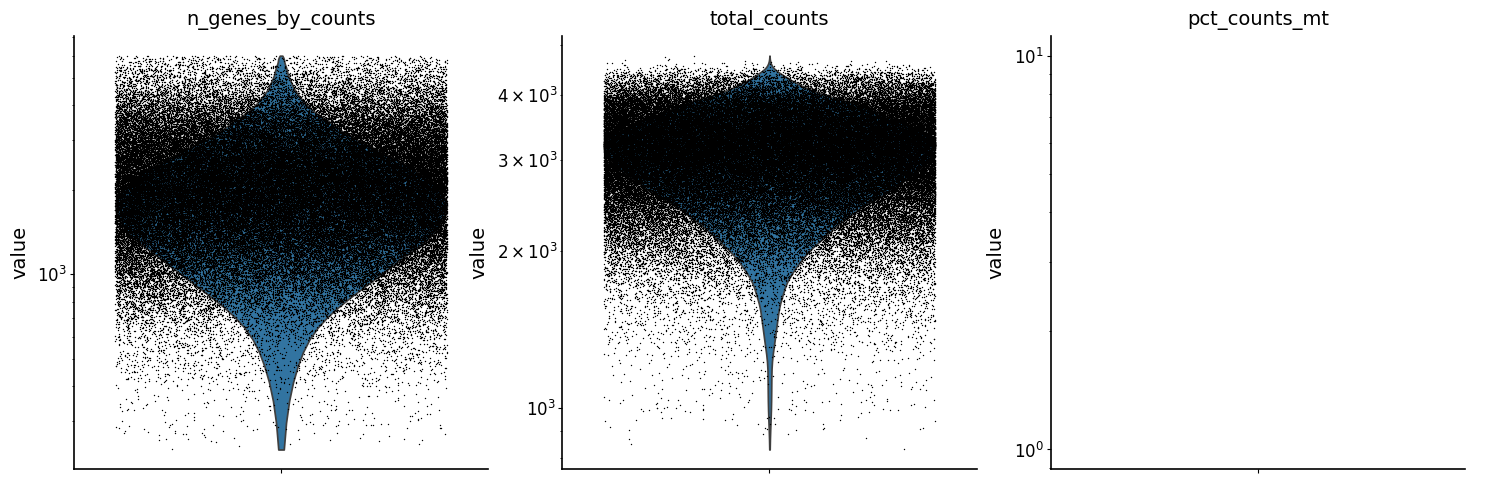

In [6]:
with mplscience.style_context():
    sc.pl.violin(mdata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
                jitter=0.4, multi_panel=True, log=True)

In [ ]:
#计算PCA
mdata.layers["counts"] = mdata.X.copy()
sc.pp.normalize_total(mdata)
sc.pp.log1p(mdata)
mdata.layers["log_normalized"] = mdata.X.copy()
sc.pp.scale(mdata)
sc.tl.pca(mdata)

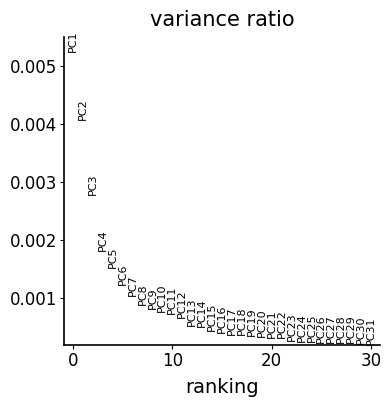

In [9]:
with mplscience.style_context():sc.pl.pca_variance_ratio(mdata)

In [10]:
mdata.layers["counts_csc"] = mdata.layers["counts"].tocsc()
hs = hotspot.Hotspot(mdata,layer_key="counts_csc",model='danb',latent_obsm_key="X_pca",umi_counts_obs_key="total_counts")

hs.create_knn_graph(
  weighted_graph=False, n_neighbors=30,
)

####计算基因自相关性
#hs_results = hs.compute_autocorrelations(jobs=4)#报错了，就不多线程了
hs_results = hs.compute_autocorrelations()
hs_results.head(15)

100%|██████████| 27942/27942 [10:56<00:00, 42.54it/s]


,C,Z,Pval,FDR
Gene,,,,
ADARB2,0.908046,1579.212593,0.0,0.0
ERBB4,0.876263,1484.825633,0.0,0.0
GRIK1,0.816276,1476.399076,0.0,0.0
NXPH1,0.821089,1414.500994,0.0,0.0
LINGO1,0.777176,1413.012846,0.0,0.0
SLC26A3,0.716530,1335.794861,0.0,0.0
BCOR,0.625496,1244.540069,0.0,0.0
RASGEF1B,0.719127,1239.833239,0.0,0.0
SOX6,0.710463,1233.138151,0.0,0.0


Computing pair-wise local correlation on 500 features...


100%|██████████| 124750/124750 [28:00<00:00, 74.25it/s] 


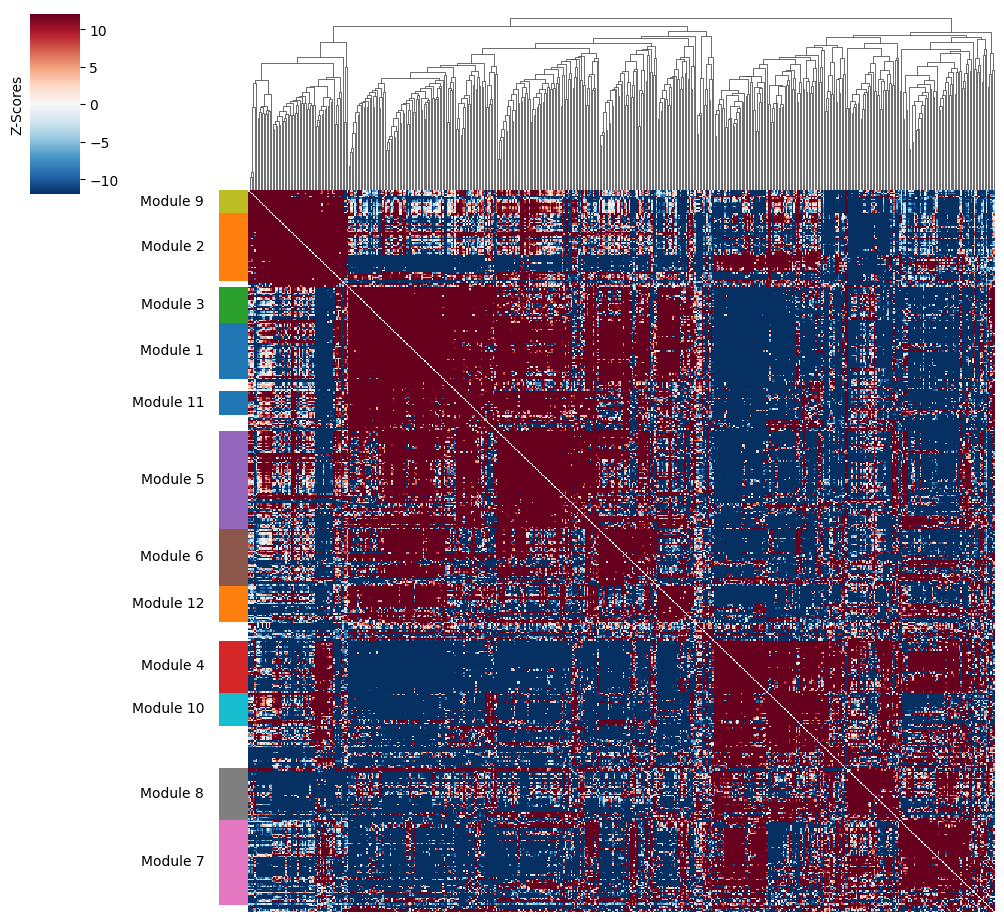

In [11]:
# Select the genes with significant lineage autocorrelation
hs_genes = hs_results.loc[hs_results.FDR < 0.05].sort_values('Z', ascending=False).head(500).index

# Compute pair-wise local correlations between these genes
#lcz = hs.compute_local_correlations(hs_genes, jobs=4)
lcz = hs.compute_local_correlations(hs_genes)

modules = hs.create_modules(
  min_gene_threshold=15, core_only=True, fdr_threshold=0.05
)

modules.value_counts()
hs.plot_local_correlations(vmin=-12, vmax=12)

In [12]:
# Show the top genes for a module
module = 9
results = hs.results.join(hs.modules)
results = results.loc[results.Module == module]
results.sort_values('Z', ascending=False).head(10)

,C,Z,Pval,FDR,Module
Gene,,,,,
LINGO1,0.777176,1413.012846,0.0,0.0,9.0
SLC26A3,0.716530,1335.794861,0.0,0.0,9.0
BCOR,0.625496,1244.540069,0.0,0.0,9.0
RASGEF1B,0.719127,1239.833239,0.0,0.0,9.0
BCYRN1,0.501434,854.544518,0.0,0.0,9.0
RPL31,0.375359,637.034300,0.0,0.0,9.0
RPL37A,0.283102,470.240541,0.0,0.0,9.0
RPL34,0.263117,431.048269,0.0,0.0,9.0
RPS27A,0.254167,414.255161,0.0,0.0,9.0


In [13]:
#Summary Module Scores
module_scores = hs.calculate_module_scores()
module_scores.head()

Computing scores for 12 modules...


100%|██████████| 12/12 [01:00<00:00,  5.03s/it]


,1,2,3,4,5,6,7,8,9,10,11,12
Nor1_AAACCCAAGGTTTACC-1,-2.384290,-4.473348,-2.104566,3.029248,-2.233513,-1.137478,0.146517,1.644914,-1.508949,-0.476149,-1.639026,0.323060
Nor1_AAACCCAAGTACTCGT-1,-2.822507,-4.248590,-1.852378,2.731047,-2.441654,-1.490430,-1.978302,0.831631,-1.485288,3.748552,-1.532889,-1.168359
Nor1_AAACCCACACGTAGAG-1,-2.757899,-4.085965,-2.051064,2.779913,-2.400978,-1.374128,-2.484354,0.961947,-1.380473,4.008597,-1.406795,-0.862526
Nor1_AAACCCAGTCAGCGTC-1,-1.796079,-4.382394,-1.783188,2.355420,-2.213701,-0.478937,-1.220319,0.428134,-1.463442,0.781638,-2.023740,0.055176
Nor1_AAACCCAGTTCGAAGG-1,-1.616256,-3.882371,-2.060097,2.563729,-2.049530,-1.060657,5.654879,0.159382,-1.376283,-1.532969,-2.468109,-0.349386


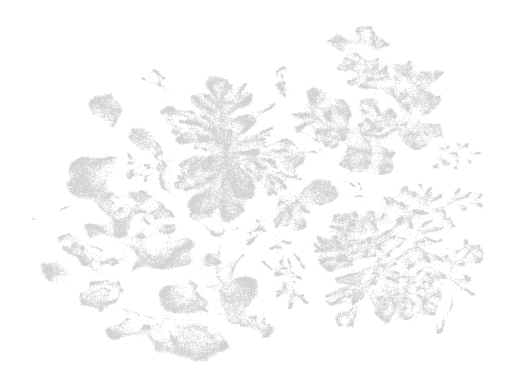

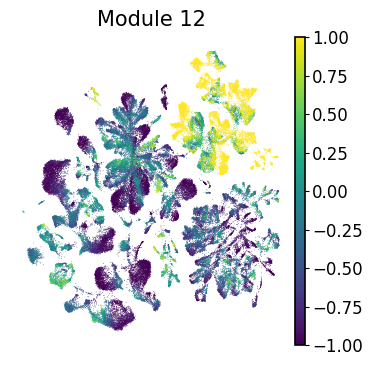

In [14]:
sc.pp.neighbors(mdata)
sc.tl.umap(mdata)
sc.pl.umap(mdata, frameon=False)

module_cols = []
for c in module_scores.columns:
  key = f"Module {c}"
mdata.obs[key] = module_scores[c]
module_cols.append(key)

with mplscience.style_context():
  sc.pl.umap(mdata, color=module_cols, frameon=False, vmin=-1, vmax=1)

In [15]:
lcz.to_csv('./temp/temp_genemodule_cor.csv', index=False)
results = hs.results.join(hs.modules)
results.to_csv('./temp/temp_genemodule.csv', index=True)